# Behavioural sequence analysis
This script is used to check the behavioural sequences and quickly see what they look like
The existing code can easily duplicated in additional cells to check other aspects of the 'parameters_per_stimuli' file

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [16]:
# Make output folder if non-existent
output_dir = os.path.join('..','plots','sequences')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [17]:
# Load the path and read the CSV
subject_id = 999

sequence_path = os.path.join('/Users', 'kenneth.van.der.zee', 'Documents', 'phd_1_task', 'resources', f'parameters_per_stimuli_sub-{subject_id:003}_session-05.csv')
sequence_dataframe = pd.read_csv(sequence_path, sep=';')

# Adding a helper column 'entry' to keep track of the count of each type
sequence_dataframe['entry'] = sequence_dataframe.groupby('stimuli_type').cumcount()

# Pivot the DataFrame using the new 'entry' column as the index
probability_dataframe_pivoted = sequence_dataframe.pivot(index = 'entry', columns = 'stimuli_type', values = 'probability_sequence')
reinforcement_dataframe_pivoted = sequence_dataframe.pivot(index = 'entry', columns = 'stimuli_type', values = 'reinforcement_sequence')
print(probability_dataframe_pivoted)

stimuli_type   1   2   3   4
entry                       
0             50  50  50  50
1             50  50  50  50
2             20  80  20  20
3             20  80  20  20
4             20  80  20  20
...           ..  ..  ..  ..
115           80  80  20  80
116           80  80  20  80
117           80  80  20  80
118           80  80  20  80
119           80  80  20  80

[120 rows x 4 columns]


## Probability sequence
### Plot all probability sequences together
As seen in Ly's paper from 2014

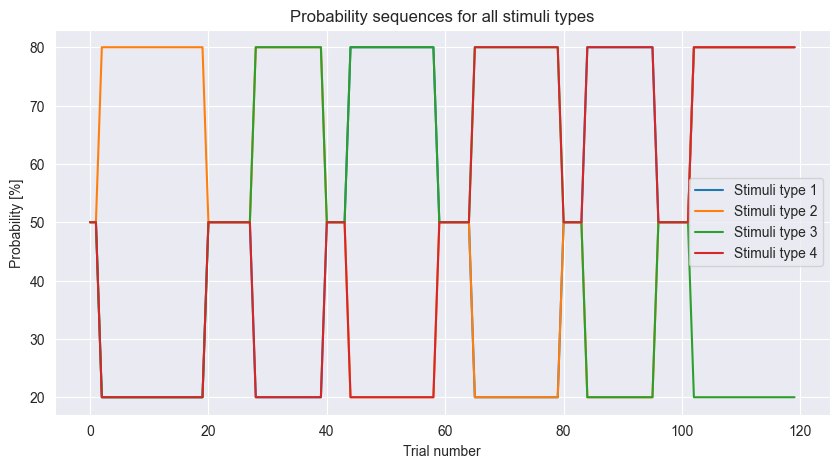

In [18]:
# Plot all stimuli types together
plt.figure(figsize=(10, 5))
for col in probability_dataframe_pivoted.columns:
    plt.plot(probability_dataframe_pivoted[col], label=f'Stimuli type {col}')
plt.title('Probability sequences for all stimuli types')
plt.xlabel('Trial number')
plt.ylabel('Probability [%]')
plt.legend()
plt.savefig(os.path.join(output_dir, f'probability_sequence_all_stimuli_types_sub-{subject_id:003}.pdf'))
plt.show()

### Now plot them separately
To take a proper look at each sequence separately

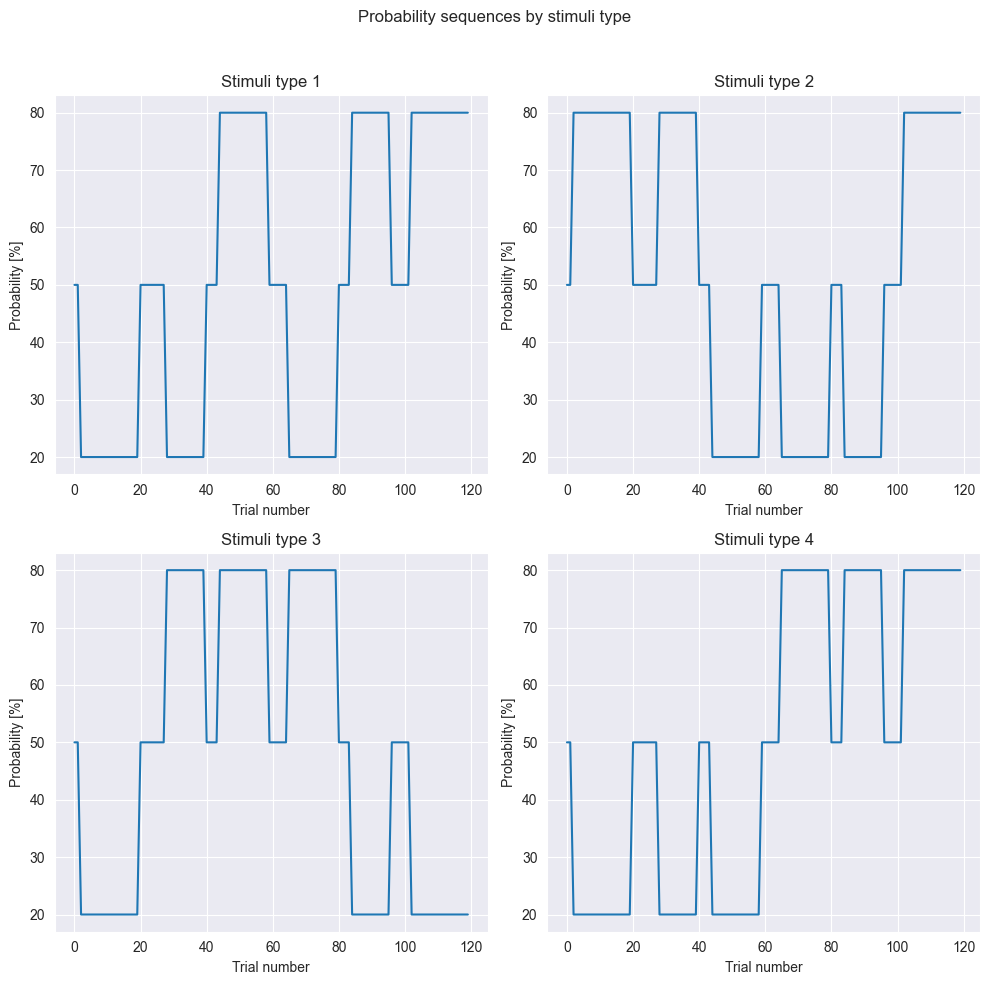

In [19]:
# Plot each stimuli type in a separate subplot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
fig.suptitle('Probability sequences by stimuli type')

for i, ax in enumerate(axes.flatten()):
    ax.plot(probability_dataframe_pivoted[i+1].dropna())  # dropna() is used because pivoting can introduce NaN values
    ax.set_title(f'Stimuli type {i+1}')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Probability [%]')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the main title
plt.savefig(os.path.join(output_dir, f'probability_sequence_per_stimuli_type_sub-{subject_id:003}.pdf'))
plt.show()

## Reinforcement sequence
Here, we plot the same things but for the reinforcement sequence instead

In [20]:
"""
# Plot all stimuli types together
plt.figure(figsize=(10, 5))
for col in reinforcement_dataframe_pivoted.columns:
    plt.plot(reinforcement_dataframe_pivoted[col], label=f'Stimuli type {col}')
plt.title('Reinforcement sequences for all stimuli types')
plt.xlabel('Trial number')
plt.ylabel('Reinforcement [bool]')
plt.legend()
plt.savefig(os.path.join(output_dir, f'reinforcement_sequence_all_stimuli_types_sub-{subject_id:003}.pdf'))
plt.show()
"""

"\n# Plot all stimuli types together\nplt.figure(figsize=(10, 5))\nfor col in reinforcement_dataframe_pivoted.columns:\n    plt.plot(reinforcement_dataframe_pivoted[col], label=f'Stimuli type {col}')\nplt.title('Reinforcement sequences for all stimuli types')\nplt.xlabel('Trial number')\nplt.ylabel('Reinforcement [bool]')\nplt.legend()\nplt.savefig(os.path.join(output_dir, f'reinforcement_sequence_all_stimuli_types_sub-{subject_id:003}.pdf'))\nplt.show()\n"

In [21]:
"""
# Plot each stimuli type in a separate subplot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
fig.suptitle('Probability sequences by stimuli type')

for i, ax in enumerate(axes.flatten()):
    ax.plot(reinforcement_dataframe_pivoted[i+1].dropna())  # dropna() is used because pivoting can introduce NaN values
    ax.set_title(f'Stimuli type {i+1}')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Reinforcement [bool]')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the main title
plt.savefig(os.path.join(output_dir, f'reinforcement_sequence_per_stimuli_type_sub-{subject_id:003}.pdf'))
plt.show()
"""

"\n# Plot each stimuli type in a separate subplot\nfig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))\nfig.suptitle('Probability sequences by stimuli type')\n\nfor i, ax in enumerate(axes.flatten()):\n    ax.plot(reinforcement_dataframe_pivoted[i+1].dropna())  # dropna() is used because pivoting can introduce NaN values\n    ax.set_title(f'Stimuli type {i+1}')\n    ax.set_xlabel('Trial number')\n    ax.set_ylabel('Reinforcement [bool]')\n\nplt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the main title\nplt.savefig(os.path.join(output_dir, f'reinforcement_sequence_per_stimuli_type_sub-{subject_id:003}.pdf'))\nplt.show()\n"